In [46]:
import pandas as pd
from googleapiclient.discovery import build


In [ ]:
API_KEY = 'Paste Your API Key Here'  
VIDEO_ID = 'test id' 


In [ ]:

youtube = build('youtube', 'v3', developerKey=API_KEY)
    
comments_list = []
    
    
request = youtube.commentThreads().list(
    part="snippet",
    videoId=VIDEO_ID,
    maxResults=100, 
    textFormat="plainText"
)
    
print(f"Fetching comments for video: {VIDEO_ID}...")

Fetching comments for video: zaGOKd4jqEk...


In [49]:
comments_list=[]
for i in range(5):
    response=request.execute()
    
    for item in response['items']:
        comment_data=item['snippet']['topLevelComment']['snippet']

        comments_list.append({
            'Author': comment_data['authorDisplayName'],
            'Comment': comment_data['textDisplay'],

        })

In [50]:
df=pd.DataFrame(comments_list)

In [51]:
df

,Author,Comment
0,@sir_no_name1478,I mean the naming alone gives it away right?\n...
1,@ryanquinn1257,"""a chance to win, decisively"" is really corpo ..."
2,@macbetabetamac8998,It’s really simple. I’m sure metho is good but...
3,@AIShip-f1q,https://youtu.be/Pia6BbOFOjs?si=Q4VSsrAGETMxynYE
4,@jonmatthis,"70% of the time, defenders win every time (dec..."
...,...,...
495,@CyrusChennault,Theres a chance to win decisively LOL
496,@pffffffffffft,You can say 'might win decisively'. It just m...
497,@kronicali24,because the AI only knnows what it's trained o...
498,@gridsleep,I don't buy anybody's flipping $18 a pound cof...


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased-finetuned-sst-2-english"

print("Downloading model and tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

local_path = "./my_local_distilbert"
tokenizer.save_pretrained(local_path)
model.save_pretrained(local_path)

print(f"Successfully downloaded and saved to: {local_path}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.11it/s]

Successfully downloaded and saved to: ./my_local_distilbert


In [ ]:
import pandas as pd
from transformers import pipeline


local_path = "./my_local_distilbert"


print("Loading model from local drive...")
sentiment_pipeline = pipeline(
    "sentiment-analysis", 
    model=local_path, 
    tokenizer=local_path,
    truncation=True 
)

df['sentiment']=[result['label'] for result in sentiment_pipeline(df['Comment'].to_list())]
print(df)

Loading model from local drive...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2609.30it/s]


                  Author                                            Comment  \
0       @sir_no_name1478  I mean the naming alone gives it away right?\n...   
1         @ryanquinn1257  "a chance to win, decisively" is really corpo ...   
2    @macbetabetamac8998  It’s really simple. I’m sure metho is good but...   
3            @AIShip-f1q   https://youtu.be/Pia6BbOFOjs?si=Q4VSsrAGETMxynYE   
4            @jonmatthis  70% of the time, defenders win every time (dec...   
..                   ...                                                ...   
495      @CyrusChennault              Theres a chance to win decisively LOL   
496       @pffffffffffft  You can say 'might win decisively'.  It just m...   
497         @kronicali24  because the AI only knnows what it's trained o...   
498           @gridsleep  I don't buy anybody's flipping $18 a pound cof...   
499            @MaBr-g9h                       Buddy has the methadone eyes   

    sentiment  
0    POSITIVE  
1    POSITIVE  
2  

In [54]:
df

,Author,Comment,sentiment
0,@sir_no_name1478,I mean the naming alone gives it away right?\n...,POSITIVE
1,@ryanquinn1257,"""a chance to win, decisively"" is really corpo ...",POSITIVE
2,@macbetabetamac8998,It’s really simple. I’m sure metho is good but...,POSITIVE
3,@AIShip-f1q,https://youtu.be/Pia6BbOFOjs?si=Q4VSsrAGETMxynYE,NEGATIVE
4,@jonmatthis,"70% of the time, defenders win every time (dec...",POSITIVE
...,...,...,...
495,@CyrusChennault,Theres a chance to win decisively LOL,POSITIVE
496,@pffffffffffft,You can say 'might win decisively'. It just m...,NEGATIVE
497,@kronicali24,because the AI only knnows what it's trained o...,NEGATIVE
498,@gridsleep,I don't buy anybody's flipping $18 a pound cof...,NEGATIVE


In [55]:
mapping_dict = {
    'POSITIVE': 1,
    'NEGATIVE': 0
}


df['sentiment_numeric'] = df['sentiment'].map(mapping_dict)

In [56]:
df

,Author,Comment,sentiment,sentiment_numeric
0,@sir_no_name1478,I mean the naming alone gives it away right?\n...,POSITIVE,1
1,@ryanquinn1257,"""a chance to win, decisively"" is really corpo ...",POSITIVE,1
2,@macbetabetamac8998,It’s really simple. I’m sure metho is good but...,POSITIVE,1
3,@AIShip-f1q,https://youtu.be/Pia6BbOFOjs?si=Q4VSsrAGETMxynYE,NEGATIVE,0
4,@jonmatthis,"70% of the time, defenders win every time (dec...",POSITIVE,1
...,...,...,...,...
495,@CyrusChennault,Theres a chance to win decisively LOL,POSITIVE,1
496,@pffffffffffft,You can say 'might win decisively'. It just m...,NEGATIVE,0
497,@kronicali24,because the AI only knnows what it's trained o...,NEGATIVE,0
498,@gridsleep,I don't buy anybody's flipping $18 a pound cof...,NEGATIVE,0


<Axes: xlabel='sentiment_numeric', ylabel='count'>

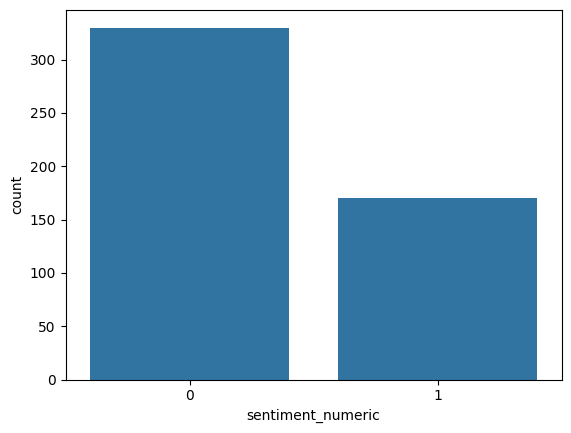

In [57]:
import seaborn as sns

sns.countplot(data=df,x='sentiment_numeric')

In [58]:
df.drop('Author',axis=1)

,Comment,sentiment,sentiment_numeric
0,I mean the naming alone gives it away right?\n...,POSITIVE,1
1,"""a chance to win, decisively"" is really corpo ...",POSITIVE,1
2,It’s really simple. I’m sure metho is good but...,POSITIVE,1
3,https://youtu.be/Pia6BbOFOjs?si=Q4VSsrAGETMxynYE,NEGATIVE,0
4,"70% of the time, defenders win every time (dec...",POSITIVE,1
...,...,...,...
495,Theres a chance to win decisively LOL,POSITIVE,1
496,You can say 'might win decisively'. It just m...,NEGATIVE,0
497,because the AI only knnows what it's trained o...,NEGATIVE,0
498,I don't buy anybody's flipping $18 a pound cof...,NEGATIVE,0


In [ ]:
import pandas as pd
import ollama


negative_df = df[df['sentiment'] == 'NEGATIVE']
positive_df = df[df['sentiment'] == 'POSITIVE']

negative_comments = negative_df['Comment'].tolist()
positive_comments = positive_df['Comment'].tolist() 

Neg_comments_text = "\n- ".join(negative_comments[:100])
pos_comment_test = "\n-".join(positive_comments[:100])

num_positive = (df['sentiment'] == 'POSITIVE').sum()
num_negative = (df['sentiment'] == 'NEGATIVE').sum()

prompt = f"""
You are an expert data analyst. I am going to give you a list of negative and postive YouTube comments.
Please read through them and give me a summary of the positive and negative comments i will also tell you what is the sentiment of top 500 comments this is just for your context 
and you should not tell how many comments are positive or negative you can use words like most , some , etc to describe the sentiments of the comments.

Here are the comments:
- negative comments - {Neg_comments_text}
- positve comments - {pos_comment_test}

and the sentiment of top 500 comment are - [positive = {num_positive}] ,[negative={num_negative}]
"""


print("Thinking... (this might take a moment depending on your computer's speed)")

response = ollama.chat(
    model='llama3.2', 
    messages=[
        {'role': 'user', 'content': prompt}
    ]
)


print("\n--- LLAMA 3.2 ANALYSIS ---")
print(response['message']['content'])

Thinking... (this might take a moment depending on your computer's speed)

--- LLAMA 3.2 ANALYSIS ---
What a delightfully mixed bag of comments!

After analyzing the top 500 comments, I'll provide a brief summary:

**Positive Sentiment (170)**

* Many users express excitement about the potential benefits of Claude Mythos, such as improved security and reduced vulnerability.
* Some commenters appreciate Primeagen's explanations of grammar and language concepts, even if they don't fully understand them.
* A few users mention that they're looking forward to trying out Claude Mythos for their projects.

**Negative Sentiment (330)**

* The majority of comments are skeptical or critical about Claude Mythos, with concerns about its potential risks and limitations.
* Many users express frustration with the marketing hype surrounding the tool, feeling that it's overhyped or exaggerated.
* Some commenters question Primeagen's credibility or expertise in explaining complex technical concepts.
* A